# ROGI vs ROGI-XD curves

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
# Directory that was passed as --plot-dir to both scripts
CURVE_DIR = Path("/data/users/mrdupont/bayesian-optimization-mmgbsa/figures")
DATA_DIR  = Path("../data")

In [6]:
df_mmgbsa = pd.read_csv(DATA_DIR / "MCL1-mmgbsa.csv")
df_vina   = pd.read_csv(DATA_DIR / "MCL1-vina.csv")

mmgbsa_std = df_mmgbsa["target"].std()
vina_std = df_vina["target"].std()

In [7]:
def load_curves(curve_dir: Path) -> pd.DataFrame:
    """Load all ROGI / ROGI-XD JSON curve files into a DataFrame.

    :param Path curve_dir: Directory containing ``rogi_*.json`` files
    :return: DataFrame with columns [method, embedding, target, score,
             uncertainty, auc, thresholds, disp_loss]
    :rtype: pd.DataFrame
    """
    records = []
    for path in sorted(curve_dir.glob("*.json")):
        with open(path) as f:
            records.append(json.load(f))
    return pd.DataFrame(records)


df = load_curves(CURVE_DIR)
df["target"] = df["target"].str.replace("MM-GBSA", "MMGBSA", regex=False)
print(df[["method", "embedding", "target", "score", "uncertainty", "auc"]])

    method  embedding  target     score  uncertainty       auc
0     ROGI  MolFormer  MMGBSA  0.159126     0.000077  0.318253
1     ROGI  MolFormer    Vina  0.209661     0.000096  0.419323
2     ROGI  Morgan FP  MMGBSA  0.065992     0.000100  0.131985
3     ROGI  Morgan FP    Vina  0.040924     0.000433  0.081847
4  ROGI-XD  MolFormer  MMGBSA  0.087995     0.000083  0.290412
5  ROGI-XD  MolFormer    Vina  0.074042     0.000115  0.364717
6  ROGI-XD  Morgan FP  MMGBSA  0.101229     0.000169  0.131985
7  ROGI-XD  Morgan FP    Vina  0.079200     0.000133  0.081847


In [8]:
df.loc[0, "disp_loss"][-1], mmgbsa_std

(0.4288624048527838, 6.1887701328419515)

FileNotFoundError: [Errno 2] No such file or directory: 'analysis/rogi_curves_MolFormer.pdf'

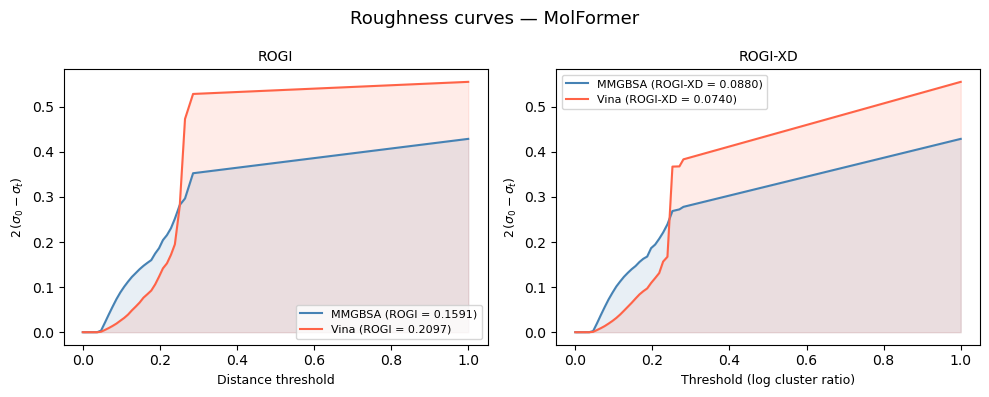

In [ ]:
X_LABELS = {
    "ROGI": "Distance threshold",
    "ROGI-XD": "Threshold (log cluster ratio)",
}

METHODS = ["ROGI", "ROGI-XD"]
TARGETS = ["MMGBSA", "Vina"]
TARGET_COLORS = {"MMGBSA": "steelblue", "Vina": "tomato"}


def plot_embedding(emb: str, df: pd.DataFrame) -> plt.Figure:
    """Plot ROGI and ROGI-XD curves for a single embedding.

    Columns = method (ROGI, ROGI-XD). MMGBSA and Vina are overlaid in
    each panel.

    :param str emb: Embedding name (e.g. 'Morgan FP')
    :param pd.DataFrame df: Full curve DataFrame
    :return: Figure
    :rtype: plt.Figure
    """
    n_cols = len(METHODS)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), squeeze=False)
    fig.suptitle(f"Roughness curves — {emb}", fontsize=13)

    for col, method in enumerate(METHODS):
        ax = axes[0][col]
        has_data = False
        for target in TARGETS:
            subset = df[
                (df["method"] == method)
                & (df["embedding"] == emb)
                & (df["target"] == target)
            ]
            if subset.empty:
                continue
            has_data = True
            row_data = subset.iloc[0]
            thresholds = np.asarray(row_data["thresholds"])
            disp_loss  = np.asarray(row_data["disp_loss"])
            score      = row_data["score"]
            color      = TARGET_COLORS.get(target)
            ax.plot(
                thresholds, disp_loss, lw=1.5, color=color,
                label=f"{target} ({method} = {score:.4f})",
            )
            ax.fill_between(thresholds, 0, disp_loss, alpha=0.12, color=color)

        if not has_data:
            ax.set_visible(False)
            continue
        ax.legend(fontsize=8)
        ax.set_xlabel(X_LABELS[method], fontsize=9)
        ax.set_ylabel(r"$2\,(\sigma_0 - \sigma_t)$", fontsize=9)
        ax.set_title(method, fontsize=10)

    fig.tight_layout()
    return fig


embeddings = df["embedding"].unique()
figures = {}
for emb in embeddings:
    fig = plot_embedding(emb, df)
    figures[emb] = fig
    fig.savefig(f"./figures/rogi_curves_{emb}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

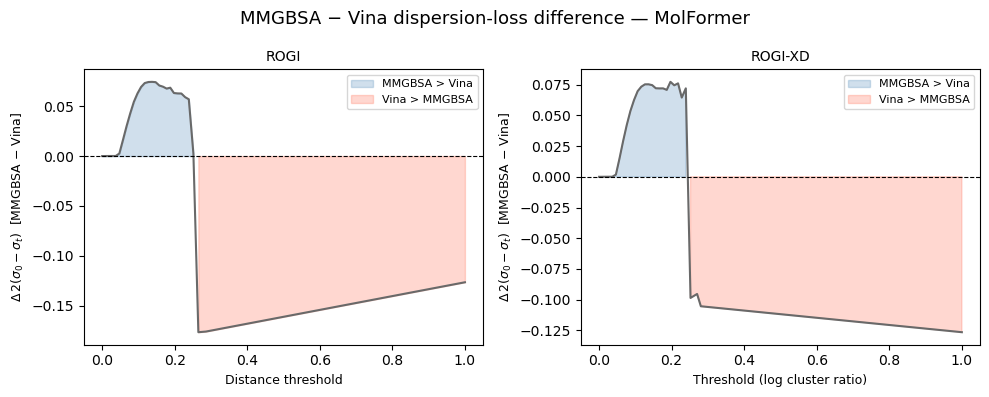

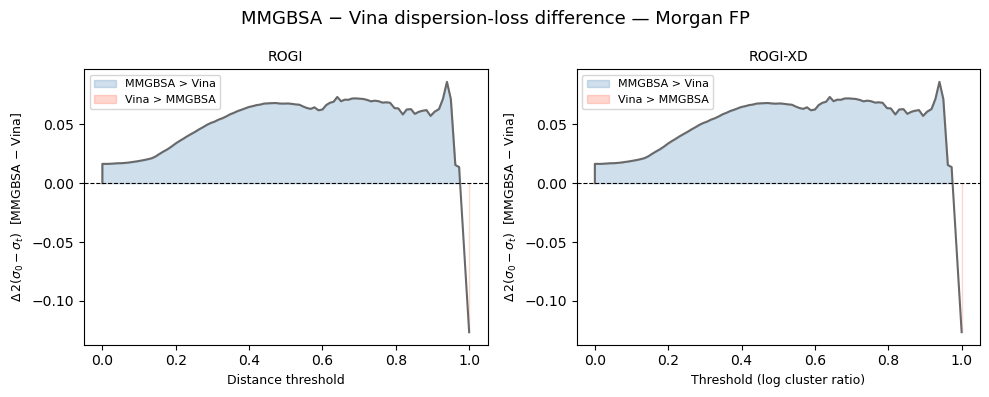

In [ ]:
for emb in embeddings:
    fig, axes = plt.subplots(1, len(METHODS), figsize=(5 * len(METHODS), 4), squeeze=False)
    fig.suptitle(f"MMGBSA − Vina dispersion-loss difference — {emb}", fontsize=13)

    for col, method in enumerate(METHODS):
        ax  = axes[0][col]
        sub = df[(df["method"] == method) & (df["embedding"] == emb)]
        row_a = sub[sub["target"] == "MMGBSA"]
        row_b = sub[sub["target"] == "Vina"]
        if row_a.empty or row_b.empty:
            ax.set_visible(False)
            continue

        t    = np.asarray(row_a.iloc[0]["thresholds"])
        diff = np.asarray(row_a.iloc[0]["disp_loss"]) - np.asarray(row_b.iloc[0]["disp_loss"])

        ax.plot(t, diff, lw=1.5, color="dimgrey")
        ax.fill_between(t, 0, diff, where=diff >= 0,
                        alpha=0.25, color=TARGET_COLORS["MMGBSA"], label="MMGBSA > Vina")
        ax.fill_between(t, 0, diff, where=diff <  0,
                        alpha=0.25, color=TARGET_COLORS["Vina"],    label="Vina > MMGBSA")
        ax.axhline(0, color="black", lw=0.8, linestyle="--")
        ax.set_xlabel(X_LABELS[method], fontsize=9)
        ax.set_ylabel(r"$\Delta\,2(\sigma_0 - \sigma_t)$  [MMGBSA − Vina]", fontsize=9)
        ax.set_title(method, fontsize=10)
        ax.legend(fontsize=8)

    fig.tight_layout()
    plt.show()


In [ ]:
# Optional: save figures
OUT_DIR = Path("../analysis/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for emb, fig in figures.items():
    safe = emb.replace(" ", "_")
    path = OUT_DIR / f"rogi_curves_{safe}.svg"
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved → {path}")

Saved → ../analysis/figures/rogi_curves_MolFormer.svg
Saved → ../analysis/figures/rogi_curves_Morgan_FP.svg
